# Queensland Parcel Report

Single-suburb workflow for downloading Queensland parcel/locality data, plotting one suburb's block-size distribution, and rendering a parcel-size map with adjoining suburb context.

In [ ]:
from pathlib import Path

import geopandas as gpd
import pandas as pd

from parcel_analytics.analysis import (
    apply_locality_filter,
    clip_parcels_to_locality_geometries,
    filter_base_lot_parcels,
    normalize_area_sqm,
    summarise_suburb_histograms,
)
from parcel_analytics.config import Bounds, load_config
from parcel_analytics.plotting import plot_parcel_size_map, plot_single_locality_histogram
from parcel_analytics.reports import dataset_paths_for_report
from parcel_analytics.source_qld import fetch_localities_geojson, fetch_parcels_geojson

In [ ]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "config" / "reports.example.yaml"
REPORT_NAME = "sunshine_coast_region"
LOCALITY_NAME = "Little Mountain"
BIN_EDGES = [0, 300, 400, 500, 600, 700, 800, 1000]
BIN_LABELS = ["<300", "300-400", "400-500", "500-600", "600-700", "700-800", "800-1000"]
MAX_BLOCK_SIZE_SQM = 1000
CONTEXT_BUFFER_DEGREES = 0.01

config = load_config(CONFIG_PATH)
report = config.reports[REPORT_NAME]
datasets = dataset_paths_for_report(config, report)

datasets

In [ ]:
if not datasets.localities_path.exists():
    fetch_localities_geojson(
        datasets.localities_path,
        localities=report.localities,
        lga=report.lga,
        bounds=report.bounds,
    )

parcel_localities = report.localities
if not parcel_localities and report.lga:
    parcel_localities = sorted(gpd.read_file(datasets.localities_path)["locality"].dropna().astype(str).unique().tolist())

if not datasets.parcels_path.exists():
    fetch_parcels_geojson(
        datasets.parcels_path,
        localities=parcel_localities,
        bounds=report.bounds,
    )

print(datasets.localities_path)
print(datasets.parcels_path)

In [4]:
localities = gpd.read_file(datasets.localities_path)
parcels = gpd.read_file(datasets.parcels_path)

locality_boundary = apply_locality_filter(localities, [LOCALITY_NAME])
locality_parcels = apply_locality_filter(parcels, [LOCALITY_NAME])
locality_parcels = filter_base_lot_parcels(locality_parcels)
locality_parcels = clip_parcels_to_locality_geometries(locality_parcels, locality_boundary)
locality_parcels = normalize_area_sqm(locality_parcels)
locality_parcels = locality_parcels.loc[locality_parcels["area_sqm"] < MAX_BLOCK_SIZE_SQM].copy()

pd.DataFrame(
    {
        "locality": [LOCALITY_NAME],
        "parcel_count_under_1000sqm": [len(locality_parcels)],
        "boundary_count": [len(locality_boundary)],
    }
)

,locality,parcel_count_under_1000sqm,boundary_count
0,Little Mountain,2637,1


In [5]:
selected_geom = locality_boundary.union_all()
minx, miny, maxx, maxy = locality_boundary.total_bounds
context_bounds = Bounds(
    min_lon=minx - CONTEXT_BUFFER_DEGREES,
    min_lat=miny - CONTEXT_BUFFER_DEGREES,
    max_lon=maxx + CONTEXT_BUFFER_DEGREES,
    max_lat=maxy + CONTEXT_BUFFER_DEGREES,
)
context_path = PROJECT_ROOT / "data" / "raw" / f"{LOCALITY_NAME.lower().replace(' ', '_')}_context_localities.geojson"

fetch_localities_geojson(context_path, bounds=context_bounds)
context_localities = gpd.read_file(context_path)
touching_localities = context_localities.loc[
    context_localities["locality"].ne(LOCALITY_NAME)
    & context_localities.geometry.touches(selected_geom)
].copy()
map_localities = gpd.GeoDataFrame(pd.concat([locality_boundary, touching_localities], ignore_index=True), geometry="geometry", crs=locality_boundary.crs)
map_locality_names = map_localities["locality"].tolist()

touching_localities[["locality", "lga"]].sort_values("locality").reset_index(drop=True)

,locality,lga
0,Baringa,Sunshine Coast Regional
1,Caloundra West,Sunshine Coast Regional
2,Corbould Park,Sunshine Coast Regional
3,Currimundi,Sunshine Coast Regional
4,Meridan Plains,Sunshine Coast Regional


In [6]:
map_parcels = apply_locality_filter(parcels, map_locality_names)
map_parcels = filter_base_lot_parcels(map_parcels)
map_parcels = clip_parcels_to_locality_geometries(map_parcels, map_localities)
map_parcels = normalize_area_sqm(map_parcels)
map_parcels = map_parcels.loc[map_parcels["area_sqm"] < MAX_BLOCK_SIZE_SQM].copy()

pd.DataFrame(
    {
        "mapped_localities": [len(map_locality_names)],
        "mapped_parcels_under_1000sqm": [len(map_parcels)],
    }
)

,mapped_localities,mapped_parcels_under_1000sqm
0,6,7611


In [7]:
histogram_table = summarise_suburb_histograms(
    locality_parcels,
    bin_edges=BIN_EDGES,
    bin_labels=BIN_LABELS,
)
locality_histogram = histogram_table.loc[LOCALITY_NAME]

locality_histogram.to_frame(name="parcel_count")

,parcel_count
size_bin,
<300,342
300-400,134
400-500,395
500-600,162
600-700,528
700-800,650
800-1000,426


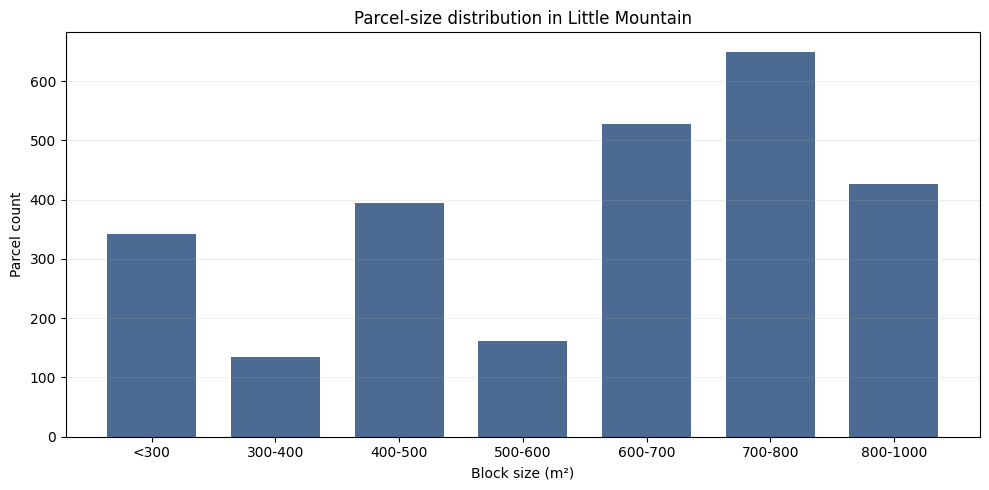

In [8]:
plot_single_locality_histogram(locality_histogram, locality_name=LOCALITY_NAME);

In [ ]:
ax = plot_parcel_size_map(map_parcels, localities=map_localities, figsize=(12, 12))
locality_boundary.boundary.plot(ax=ax, color="#C44E00", linewidth=1.8);